## Importación de librerías

In [1]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, \
    classification_report

%matplotlib inline

sns.set_theme()


## Carga del dataset

In [2]:
# 1. Cargar los datasets enriquecidos pre-procesados

df_train = ""
df_test = ""

df_train = pd.read_csv('../../../dataset/oulad/generated/dataset_train_2013_enriquecido.csv')
df_test = pd.read_csv('../../../dataset/oulad/generated/dataset_test_2014_enriquecido.csv')

# Separamos las clases del año 2013
df_train_exito = df_train[df_train['target_burnout'] == 0]
df_train_riesgo = df_train[df_train['target_burnout'] == 1]

# Reducimos la clase de éxito a la mitad (50%) aleatoriamente con semilla fija
df_train_exito_reducido = df_train_exito.sample(frac=0.5, random_state=42)

# Volvemos a unir y mezclamos (shuffle) para que el algoritmo no lea en orden
df_train = pd.concat([df_train_exito_reducido, df_train_riesgo]).sample(frac=1, random_state=42)
# ====================================================================

# 2. Separar características (X) y variable objetivo (y)
X_train = df_train.drop(columns=['target_burnout'], errors='ignore')
y_train = df_train['target_burnout']

X_test = df_test.drop(columns=['target_burnout'], errors='ignore')
y_test = df_test['target_burnout']

# 3. Comprobación de la distribución tras el balanceo
print("--- DISTRIBUCIÓN TRAS EL BALANCEO (DATASET ENRIQUECIDO) ---")
print(f"Train 2013 - Total: {len(X_train)} | Riesgo (1): {y_train.sum()} | Éxito (0): {len(y_train) - y_train.sum()}")
print(f"Test 2014  - Total: {len(X_test)} | Riesgo (1): {y_test.sum()} | Éxito (0): {len(y_test) - y_test.sum()}")
print(f"\nNúmero de características (columnas) para el modelo: {X_train.shape[1]}")

--- DISTRIBUCIÓN TRAS EL BALANCEO (DATASET ENRIQUECIDO) ---
Train 2013 - Total: 7245 | Riesgo (1): 3348 | Éxito (0): 3897
Test 2014  - Total: 10801 | Riesgo (1): 3693 | Éxito (0): 7108

Número de características (columnas) para el modelo: 29


## Entrenamieto

In [3]:
# 1. Definición de columnas actualizadas al dataset enriquecido
cat_cols = ['highest_education']

num_cols = [
    'num_of_prev_attempts', 'studied_credits',
    'total_clicks_90d', 'media_clicks_semanales', 'total_dias_activos',
    'semanas_con_actividad', 'semanas_actividad_plena', 'max_clicks_1_dia',
    'semanas_sin_clicks', 'dias_sin_clicks_90d',
    'entregas_realizadas_90d', 'nota_media_90d', 'retraso_medio_dias', 'total_entregas_tardias',
    'clicks_semana_0', 'clicks_semana_1', 'clicks_semana_2', 'clicks_semana_3',
    'clicks_semana_4', 'clicks_semana_5', 'clicks_semana_6', 'clicks_semana_7',
    'clicks_semana_8', 'clicks_semana_9', 'clicks_semana_10', 'clicks_semana_11',
    'clicks_semana_12'
]

# 2. Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

# 3. Calcular el ratio dinámico para XGBoost (se adapta a tu undersampling previo)
peso_minoritaria = float(y_train.value_counts()[0]) / y_train.value_counts()[1]
print(f"Ratio de desbalanceo ajustado tras undersampling: {peso_minoritaria:.2f}")

"""
Mejores hiprparametros
 - learning_rate: 0.1
 - max_depth: 3
 - min_child_weight: 10
 - n_estimators: 100
 - scale_pos_weight: 1.745967741935484
"""

# 4. Pipeline Optimizado XGBoost
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        learning_rate=0.1,
        max_depth=3,
        min_child_weight=10,
        n_estimators=100,
        scale_pos_weight=1.745967741935484,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# 5. Entrenar modelo
xgb_pipeline.fit(X_train, y_train)

# 6. Generar predicciones
y_pred = xgb_pipeline.predict(X_test)

print("¡Entrenamiento de XGBoost finalizado con éxito!")

Ratio de desbalanceo ajustado tras undersampling: 1.16
¡Entrenamiento de XGBoost finalizado con éxito!


## Evaluación y Gráficas de Rendimiento

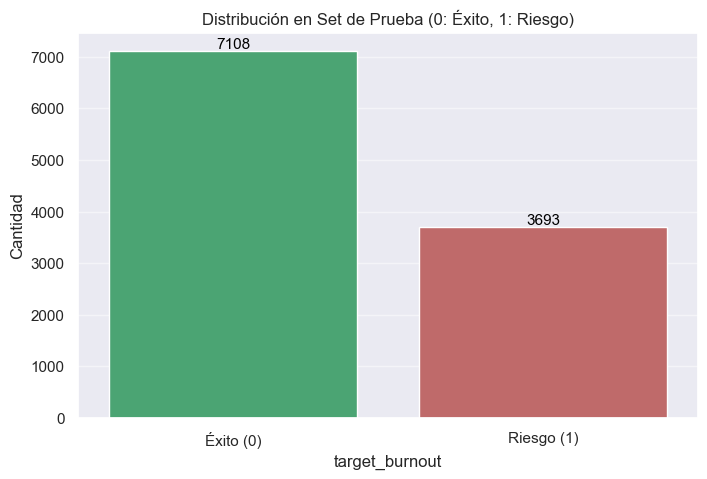

--- REPORTE DE CLASIFICACIÓN DETALLADO (Umbral: 0.63) ---
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      7108
           1       0.68      0.80      0.73      3693

    accuracy                           0.80     10801
   macro avg       0.78      0.80      0.79     10801
weighted avg       0.81      0.80      0.80     10801



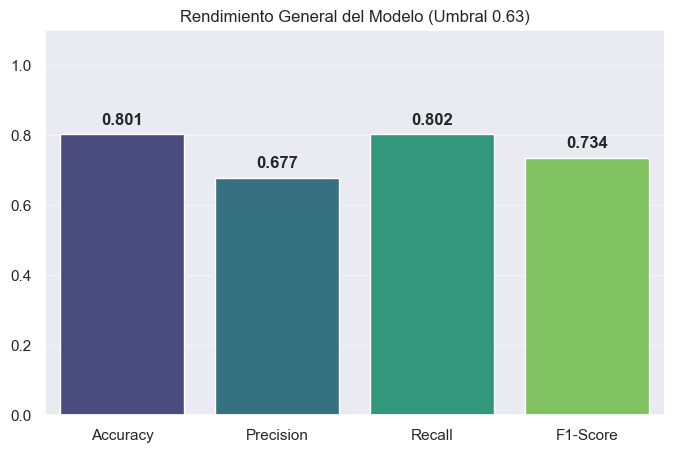

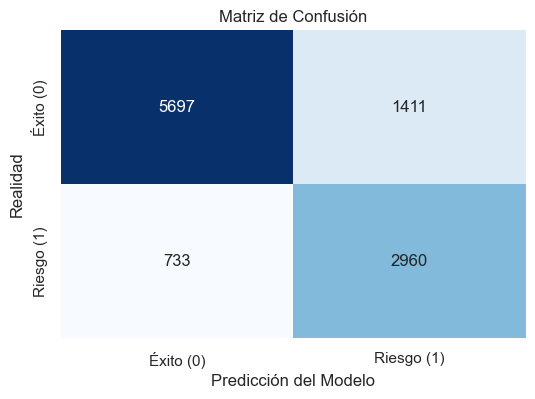

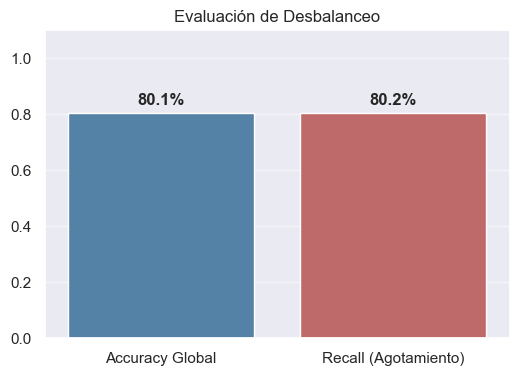

In [4]:
y_probs = xgb_pipeline.predict_proba(X_test)[:, 1]

# UMBRAL PERMISIVO
umbral_permisivo = 0.63
y_pred = (y_probs >= umbral_permisivo).astype(int)

fig1 = plt.figure(figsize=(8, 5))

ax1 = sns.countplot(x=y_test, hue=y_test, palette=['#3CB371', '#CD5C5C'], legend=False)
plt.title('Distribución en Set de Prueba (0: Éxito, 1: Riesgo)')
plt.xticks(ticks=[0, 1], labels=['Éxito (0)', 'Riesgo (1)'])
plt.ylabel('Cantidad')

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

# ==========================================
# CÁLCULO DE MÉTRICAS Y REPORTE
# ==========================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"--- REPORTE DE CLASIFICACIÓN DETALLADO (Umbral: {umbral_permisivo}) ---")
print(classification_report(y_test, y_pred, zero_division=0))

# ==========================================
# GRÁFICO 2: Visualización de Métricas Habituales
# ==========================================
fig2 = plt.figure(figsize=(8, 5))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc, prec, rec, f1]
ax2 = sns.barplot(x=metrics_names, y=metrics_values, hue=metrics_names, palette='viridis', legend=False)
plt.title(f'Rendimiento General del Modelo (Umbral {umbral_permisivo})')
plt.ylim(0, 1.1)

for i, v in enumerate(metrics_values):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')
plt.show()

# ==========================================
# GRÁFICO 3: Matriz de Confusión
# ==========================================
cm = confusion_matrix(y_test, y_pred)

fig3 = plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Éxito (0)', 'Riesgo (1)'],
            yticklabels=['Éxito (0)', 'Riesgo (1)'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad')
plt.show()

# ==========================================
# GRÁFICO 4: Accuracy Global vs Recall Minoritario
# ==========================================
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
burnout_recall = report_dict['1']['recall']

fig4 = plt.figure(figsize=(6, 4))

metric_names_comp = ['Accuracy Global', 'Recall (Agotamiento)']
metric_values_comp = [acc, burnout_recall]
ax4 = sns.barplot(x=metric_names_comp, y=metric_values_comp, hue=metric_names_comp, palette=['#4682B4', '#CD5C5C'],
                  legend=False)
plt.title('Evaluación de Desbalanceo')
plt.ylim(0, 1.1)

for i, v in enumerate(metric_values_comp):
    ax4.text(i, v + 0.02, f"{v * 100:.1f}%", ha='center', va='bottom', fontweight='bold')
plt.show()

## Grid search

In [5]:
# ==========================================
# 1. CONFIGURACIÓN DEL ESPACIO DE BÚSQUEDA
# ==========================================
# Usamos el prefijo 'classifier__' para acceder al Random Forest dentro del Pipeline
# Asumiendo 'peso_minoritaria' ya estq calculado
param_grid = {
    # 1. Volumen de árboles (Boosting rounds)
    'classifier__n_estimators': [50, 100, 200],

    # 2. Profundidad
    'classifier__max_depth': [3, 5, 7, 10],

    # 3. Tasa de aprendizaje
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],

    # 4. Equivalente a min_samples_leaf
    'classifier__min_child_weight': [1, 5, 10],

    # 5. Desbalanceo de clases
    'classifier__scale_pos_weight': [1, peso_minoritaria, peso_minoritaria * 1.5, 5, 10]
}

print("Iniciando Grid Search...")
print("Entrenando múltiples combinaciones mediante validación cruzada (CV=3)...")

# ==========================================
# 2. EJECUCIÓN DE LA BÚSQUEDA
# ==========================================
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Ejecutar el entrenamiento
grid_search.fit(X_train, y_train)

# ==========================================
# 3. RESULTADOS DE LA OPTIMIZACIÓN
# ==========================================
print("\n" + "=" * 50)
print("¡BÚSQUEDA FINALIZADA!")
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f" - {param.replace('classifier__', '')}: {value}")
print("=" * 50)

# ==========================================
# 4. PRUEBA RÁPIDA CON EL MODELO GANADOR
# ==========================================
mejor_modelo = grid_search.best_estimator_

# Evaluamos con el umbral que te estaba funcionando bien antes (0.15)
umbral_prueba = 0.15
y_probs_grid = mejor_modelo.predict_proba(X_test)[:, 1]
y_pred_grid = (y_probs_grid >= umbral_prueba).astype(int)

print(f"\n--- REPORTE DEL MEJOR MODELO (Umbral: {umbral_prueba}) ---")
print(classification_report(y_test, y_pred_grid, zero_division=0))

print("=" * 65)
print(" BUSCANDO EL UMBRAL ÓPTIMO PARA EL MODELO GANADOR")
print("=" * 65)
print(f"{'Umbral':<8} | {'Accuracy Global':<18} | {'Recall (Riesgo)':<18} | {'Precisión (Riesgo)':<18}")
print("-" * 65)

# Probamos umbrales normales/altos, ya que el modelo ya es sensible de por sí
umbrales_prueba = np.arange(0.30, 0.85, 0.05)

for u in umbrales_prueba:
    y_pred_temp = (y_probs_grid >= u).astype(int)

    acc = accuracy_score(y_test, y_pred_temp)
    rec = recall_score(y_test, y_pred_temp, zero_division=0)
    prec = precision_score(y_test, y_pred_temp, zero_division=0)

    print(f"{u:.2f}     | {acc * 100:>5.1f}%             | {rec * 100:>5.1f}%             | {prec * 100:>5.1f}%")

Iniciando Grid Search...
Entrenando múltiples combinaciones mediante validación cruzada (CV=3)...
Fitting 3 folds for each of 720 candidates, totalling 2160 fits

¡BÚSQUEDA FINALIZADA!
Mejores hiperparámetros encontrados:
 - learning_rate: 0.1
 - max_depth: 3
 - min_child_weight: 10
 - n_estimators: 100
 - scale_pos_weight: 1.745967741935484

--- REPORTE DEL MEJOR MODELO (Umbral: 0.15) ---
              precision    recall  f1-score   support

           0       0.96      0.17      0.29      7108
           1       0.38      0.99      0.55      3693

    accuracy                           0.45     10801
   macro avg       0.67      0.58      0.42     10801
weighted avg       0.76      0.45      0.38     10801

 BUSCANDO EL UMBRAL ÓPTIMO PARA EL MODELO GANADOR
Umbral   | Accuracy Global    | Recall (Riesgo)    | Precisión (Riesgo)
-----------------------------------------------------------------
0.30     |  62.6%             |  94.3%             |  47.6%
0.35     |  66.6%             | 

## SHAP

C:\Users\joseb\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



 GENERANDO EXPLICACIONES DEL MODELO GANADOR CON SHAP


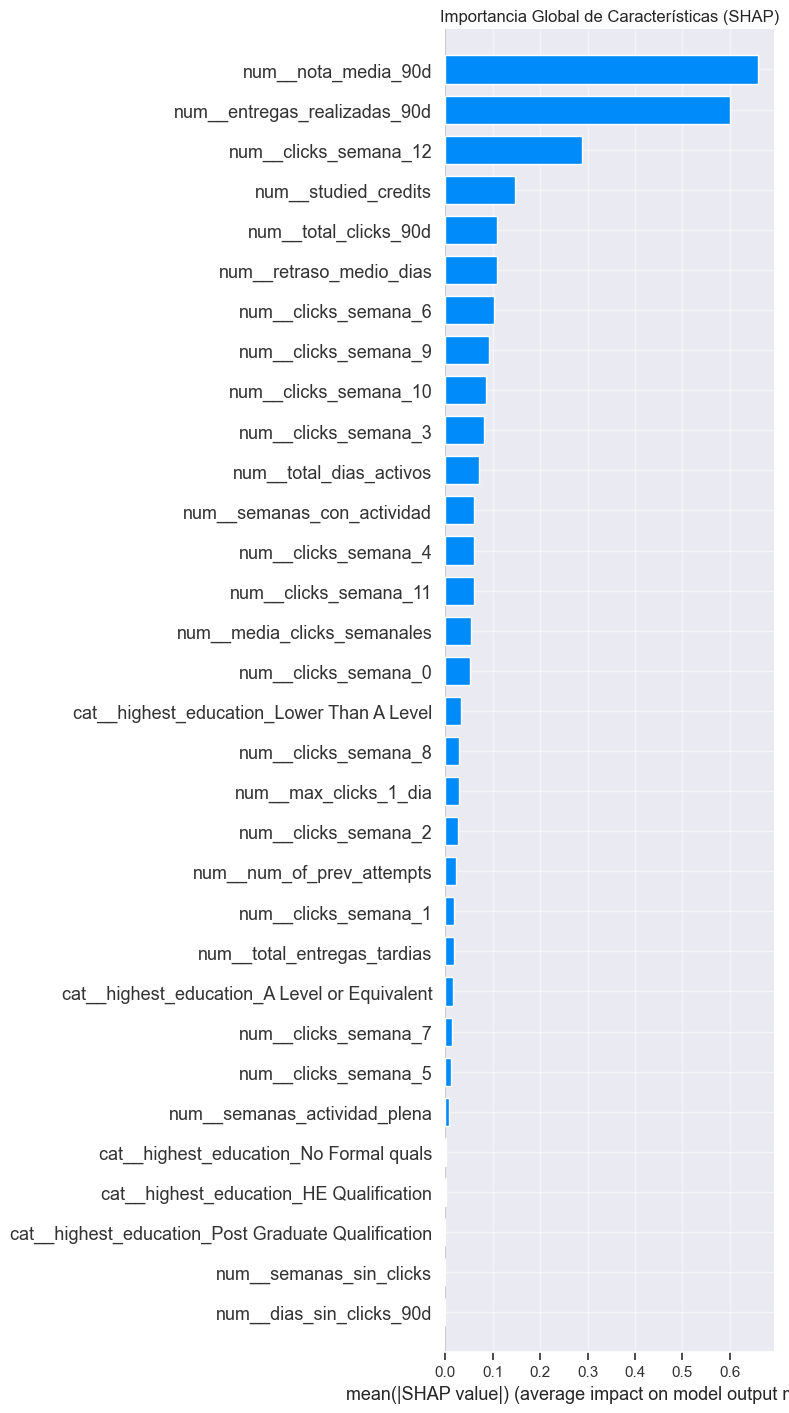

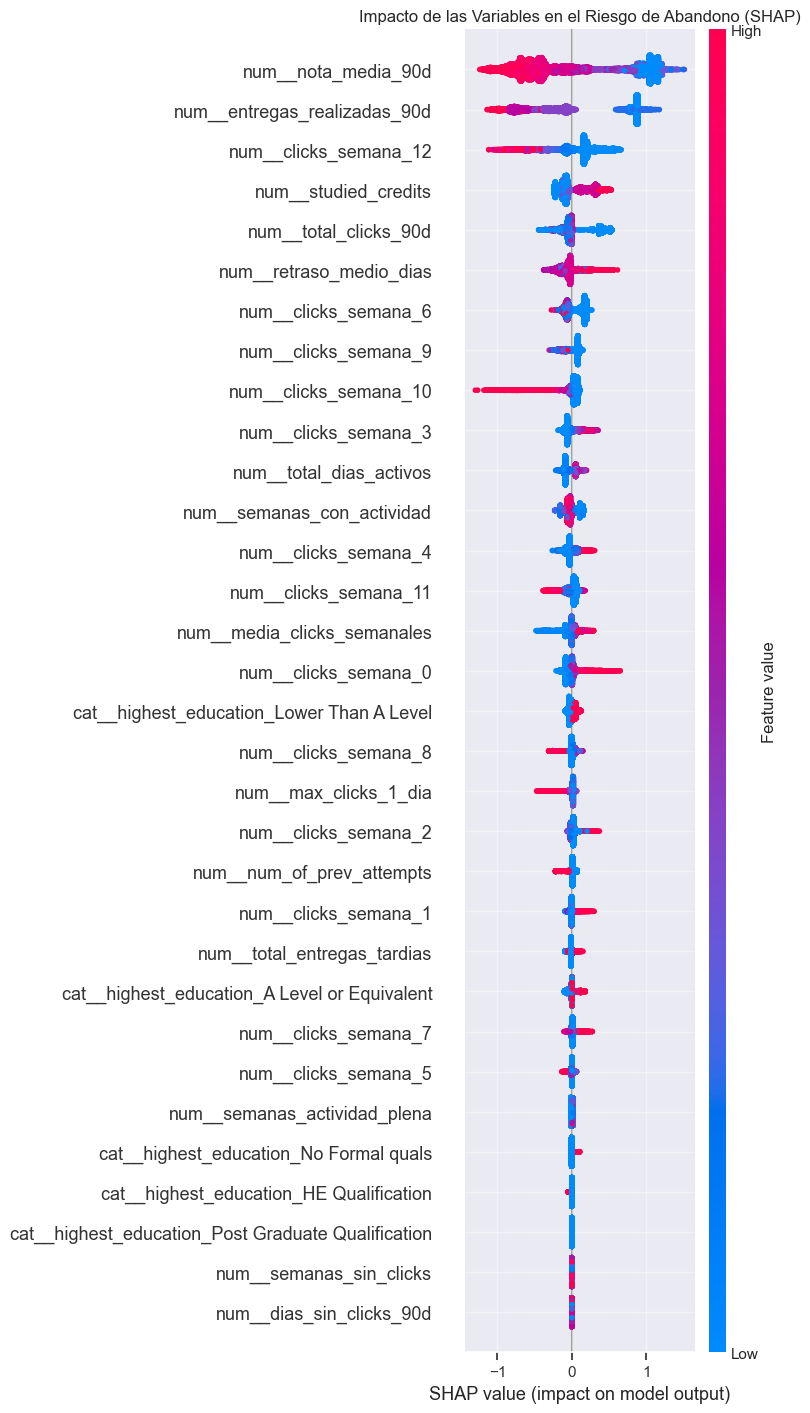


Generando explicación individual (Waterfall Plot)...


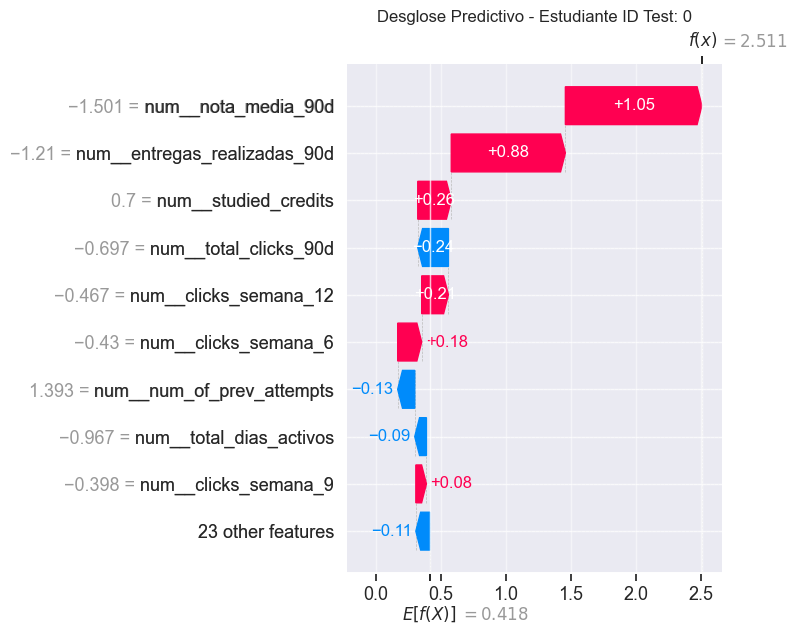

In [6]:
import shap

print("\n" + "=" * 65)
print(" GENERANDO EXPLICACIONES DEL MODELO GANADOR CON SHAP")
print("=" * 65)

# 1. Extraer el modelo XGBoost puro y el preprocesador del Pipeline ganador
modelo_puro = mejor_modelo.named_steps['classifier']
preprocesador_ganador = mejor_modelo.named_steps['preprocessor']

# 2. Transformar los datos de prueba (X_test) para que SHAP los entienda
X_test_transformado = preprocesador_ganador.transform(X_test)

# Extraer los nombres reales de las columnas tras el OneHotEncoder
nombres_columnas = preprocesador_ganador.get_feature_names_out()

# Reconstruir el DataFrame con los datos ya escalados y sus nombres
X_test_shap = pd.DataFrame(X_test_transformado, columns=nombres_columnas)

# Limpiar los caracteres inválidos ( [, ], < ) reemplazándolos por un guion bajo
X_test_shap.columns = X_test_shap.columns.str.replace(r"[\[\]<]", "_", regex=True)

# 3. Inicializar el explicador matemático (TreeExplainer es específico para árboles)
explainer = shap.TreeExplainer(modelo_puro)
shap_values = explainer.shap_values(X_test_shap)

# 4. Generar Gráfico 1: Importancia global (Barras)
plt.figure(figsize=(10, 8))  # Aumentamos un poco el alto para que quepan bien
shap.summary_plot(shap_values, X_test_shap, plot_type="bar",
                  max_display=X_test_shap.shape[1],  # <--- AQUÍ ESTÁ EL CAMBIO
                  show=False)
plt.title("Importancia Global de Características (SHAP)")
plt.tight_layout()
plt.show()

# 5. Generar Gráfico 2: Impacto direccional (Puntos)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_shap,
                  max_display=X_test_shap.shape[1],  # <--- AQUÍ ESTÁ EL CAMBIO
                  show=False)
plt.title("Impacto de las Variables en el Riesgo de Abandono (SHAP)")
plt.tight_layout()
plt.show()

print("\nGenerando explicación individual (Waterfall Plot)...")
explicacion_completa = explainer(X_test_shap)
indice_estudiante = 0
shap.plots.waterfall(explicacion_completa[indice_estudiante], max_display=10, show=False)
plt.title(f"Desglose Predictivo - Estudiante ID Test: {indice_estudiante}")
plt.tight_layout()
plt.show()